# Optimising combination of BMP4 and RT
We have shown that combination of BMP4 and RT is most effective, we want to now have a brief look at how best to optimise this treatment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.gridspec import GridSpec

import gsc_model_functions as gmf

In [2]:
def rad_times(t_start):
    # RT schedule is 5 days on with two days off for 6 weeks (30 fractions over 42 days)
    x = np.zeros(30)
    x[0] = t_start
    for i in range(1,len(x)):
        if i % 5 !=0:
            x[i] = x[i-1]  + 1
        else:
            x[i] = x[i-1]  + 3
    return x

def diff_fun(P_min, P_max, psi, B):
    return P_min + (P_max - P_min) * (1 / (1 + psi*B ) )

def simulate_till(t_max,delta_treat,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, dose = 2, alpha=0.3, beta=0.03, eta = 0.13, mu = 0.5, psi = 0, detect_size = 0.35, threshold = 1.2):
    t = np.arange(0,t_max+dt,dt)
    u = np.zeros((len(t), n+1))
    u[0] = u0

    BMP4 = 100 # Constant BMP4 delivery
    P_min = 0
    p_max = Ps

    t_BMP4_start = -1
    t_BMP4_end = -1
    t_rad = np.array([-1,-2])

    treatmant = 0 
    size_at_detect = 0

    b = False
    i = 0

    # simulate until tumor size has increase 20% from detection
    for i in range(len(t)-1):


        if np.sum(u[i,:]) > size_at_detect*1.2 and treatmant == 1 and ind_detect !=0:
            t_final = t[i]
            ind_final = i
            b = True
            break

        # tumor is detected at a given size and treatment is started
        if ( np.sum(u[i, :]) >= detect_size ) and treatmant == 0:
            treatmant = 1 # start treatment
            ind_detect = i
            treat_start = t[i]
            size_at_detect = np.sum(u[i,:])

    
        if treatmant == 1:
            
            if delta_treat < 0: # BMP4 starts first
                t_rad = rad_times(treat_start - delta_treat)
                t_BMP4_start = treat_start
                t_BMP4_end = t_BMP4_start + 42
            
            elif delta_treat > 0: # RT starts first
                t_rad = rad_times(treat_start)
                t_BMP4_start = t_rad[0] + delta_treat
                t_BMP4_end = t_BMP4_start + 42
                
            else: # BMP4 and RT start at the same time
                t_rad = rad_times(treat_start)
                t_BMP4_start = treat_start
                t_BMP4_end = t_BMP4_start + 42
        
        if (t[i] > t_BMP4_start and t[i] <= t_BMP4_end):
            Ps = diff_fun(P_min, p_max, psi, BMP4)
        else:
            Ps = p_max

        u[i+1,:] = u[i,:] + dt * gmf.gsc_model_dudt(u[i,:], n, Ps, k, ms, mv, delta_s, delta_v,r)

        if t[i] in t_rad:
            u[i+1,:] = gmf.radiation(u[i,:],alpha,beta,eta,mu,dose,n)
        

    if b:
        # crop arrays
        t = t[:ind_final+1]
        u = u[0:ind_final+1,:]


    return t,u, t_final, treat_start, size_at_detect, t_rad

def plot_fractions(t,u,ax):
    total = np.sum(u, axis=1)
    GSC_frac = u[:,0]/total
    PC_frac = np.sum(u[:,1:-1], axis=1)/total
    TDC_frac = u[:,-1]/total
    
    ax.plot(t,GSC_frac, color = 'red', linestyle = '--', label = "GSCs", linewidth=2.5)
    ax.plot(t,PC_frac, color = 'orange', label = "PCs", linewidth=2.5)
    ax.plot(t,TDC_frac, color = 'green', linestyle = '-.', label = "TDCs", linewidth=2.5)

In [3]:
# params for model simulation
dt = 0.1
t_max = 1000
n = 10 
r = np.zeros(n)
r[0] = 1
Ps = 0.6
k = 1
ms = 0.05
mv = np.ones(n)*0.05
mv[-1] = 0
delta_s = 0.0005
delta_v = np.ones(n)*0.01
# BMP4 sensitvity
psi = 0.1
# RT sensitviety
alpha = 0.09
beta = 0.009

IC = 0.01


u0 = np.zeros(n+1)
u0[0] = IC


t_rad = rad_times(100)

# delta_treat: t_rad[0] - t_BMP4_start
delta_treat = np.arange(-10,50+1,1)

u_save = []
t_save = []
t_final_save = []
treat_start_save = []
size_at_detect_save = []
t_rad_save = []

for i in range(len(delta_treat)):
    
    del_treat = delta_treat[i]
    t, u, t_final, treat_start, size_at_detect, t_rad = simulate_till(t_max,del_treat,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r,alpha = alpha, beta=beta, psi = psi)
    t_save.append(t)
    u_save.append(u)
    t_final_save.append(t_final)
    treat_start_save.append(treat_start)
    size_at_detect_save.append(size_at_detect)
    t_rad_save.append(t_rad)


# simulate radiotherapy only psi = 0 means no effect of BMP4.
t_rad_only, u_rad_only, t_final_rad_only, treat_start_rad_only, size_at_detect_rad_only, t_rad_rad_only = simulate_till(t_max,0,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r,alpha = alpha, beta=beta, psi = 0)

0.4209722543183438


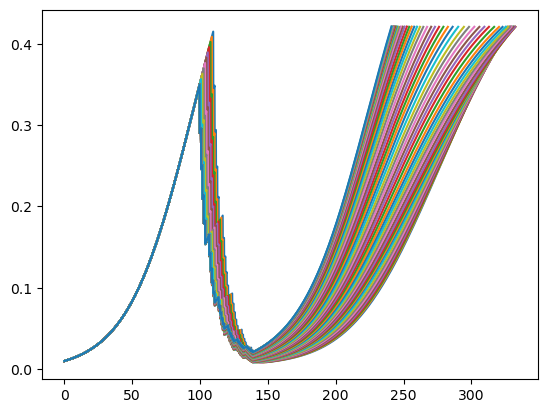

In [4]:
# final size
print( np.sum(u_save[0][-1,:]))

# get array of total tumor size
N = np.sum(u_save[0], axis=1)

for i in range(len(delta_treat)):
    N_i = np.sum(u_save[i], axis=1)

    plt.plot(t_save[i], N_i, label = f"Delta treat = {delta_treat[i]:.1f} days")

In [5]:
# time till final tumor size reaches 120% of detection size
time_20  = np.array(t_final_save)-np.array(treat_start_save)

# find the max
max_time20 = np.max(time_20)
ind_max = np.argmax(time_20)
ind_max

rad_only_survival = t_final_rad_only - treat_start_rad_only

In [6]:
plt.rcParams['hatch.linewidth'] = 7
def add_treatment_boxes(ax, delta_treat, treat_start, size_at_detect, t_rad, y_size):

    if delta_treat < 0: # BMP4 starts first
        t_BMP4_start = treat_start
        t_BMP4_end = t_BMP4_start + 42
        t_rad_start = t_rad[0]
        t_rad_end = t_rad[-1] + 2 # add 2 days to incllude the last 2 rest days so it is equal to BMP4

        rect_BMP4 = matplotlib.patches.Rectangle((t_BMP4_start,0), t_rad_start - t_BMP4_start, y_size, color='blue', alpha = 0.5) 
        rect_RT = matplotlib.patches.Rectangle((t_BMP4_end,0),  t_rad_end - t_BMP4_end, y_size, color='yellow', alpha = 0.5)

        rect_overlap = matplotlib.patches.Rectangle( (t_rad_start,0), t_BMP4_end - t_rad_start, y_size, facecolor='yellow', edgecolor='blue',hatch='/', linewidth=0, alpha = 0.5)

    elif delta_treat > 0: # RT starts first
        t_BMP4_start = t_rad[0] + delta_treat
        t_BMP4_end = t_BMP4_start + 42
        t_rad_start = t_rad[0]
        t_rad_end = t_rad[-1] + 2 # add 2 days to incllude the last 2 rest days so it is equal to BMP4

        rect_BMP4 = matplotlib.patches.Rectangle((t_rad_end,0), t_BMP4_end - t_rad_end, y_size, color='blue', alpha = 0.5)
        rect_RT = matplotlib.patches.Rectangle((t_rad_start,0),  t_BMP4_start - t_rad_start, y_size, color='yellow', alpha = 0.5)
        
        rect_overlap = matplotlib.patches.Rectangle( (t_BMP4_start,0), t_rad_end - t_BMP4_start, y_size, facecolor='yellow', edgecolor='blue',hatch='/', linewidth=0, alpha = 0.5)
        
    ax.add_patch(rect_RT)
    ax.add_patch(rect_BMP4)
    ax.add_patch(rect_overlap)

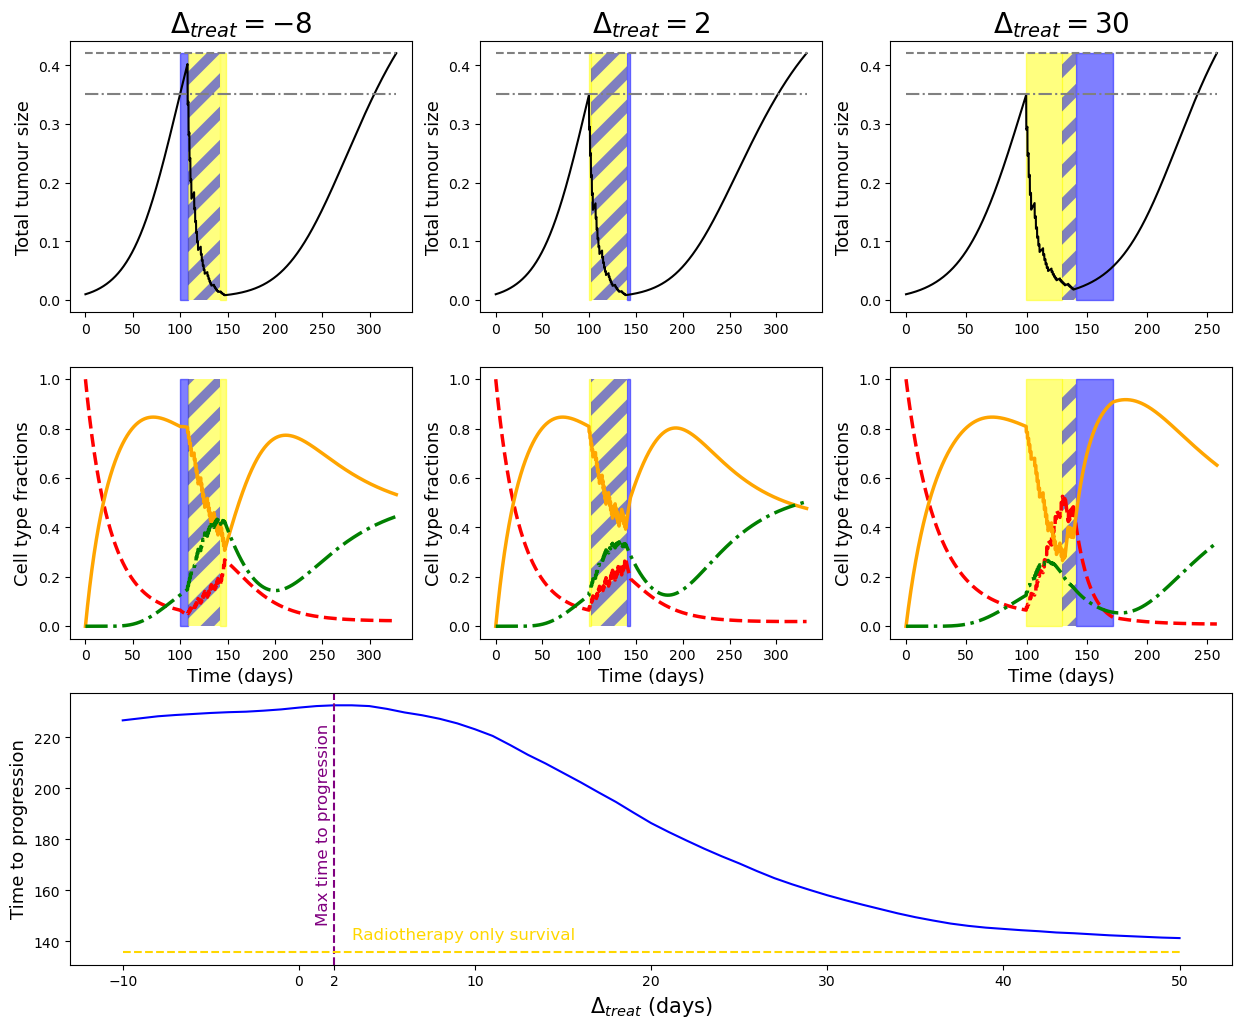

In [7]:
fig = plt.figure(figsize=(15, 12))

gs = GridSpec(3, 3, figure=fig, height_ratios=[1,1,1])

# top row: 4 separate plots
ax_top1 = fig.add_subplot(gs[0, 0])
ax_top2 = fig.add_subplot(gs[0, 1], sharey=ax_top1)
ax_top3 = fig.add_subplot(gs[0, 2], sharey=ax_top1 )



# midel row 
ax_mid1 = fig.add_subplot(gs[1, 0], sharex=ax_top1)
ax_mid2 = fig.add_subplot(gs[1, 1], sharex=ax_top2, sharey=ax_mid1)
ax_mid3 = fig.add_subplot(gs[1, 2], sharex=ax_top3, sharey=ax_mid1)

# plot example time courses for three different delta_treat values
example_indices = [np.where(delta_treat == -8)[0][0], ind_max, np.where(delta_treat == 30)[0][0]]
example_labels = [f'$\Delta_{{treat}}={delta_treat[idx]}$' for idx in example_indices]
example_axes = [ax_top1, ax_top2, ax_top3]

# add treatment boxes
add_treatment_boxes(ax_top1, delta_treat[example_indices[0]], treat_start_save[example_indices[0]], size_at_detect_save[example_indices[0]], t_rad_save[example_indices[0]], size_at_detect_save[example_indices[0]]*1.2)
add_treatment_boxes(ax_top2, delta_treat[example_indices[1]], treat_start_save[example_indices[1]], size_at_detect_save[example_indices[1]], t_rad_save[example_indices[1]], size_at_detect_save[example_indices[1]]*1.2)
add_treatment_boxes(ax_top3, delta_treat[example_indices[2]], treat_start_save[example_indices[2]], size_at_detect_save[example_indices[2]], t_rad_save[example_indices[2]], size_at_detect_save[example_indices[2]]*1.2)

for ax, idx, label in zip(example_axes, example_indices, example_labels):
    ax.plot(t_save[idx], np.sum(u_save[idx], axis=1), color = 'k')
    ax.set_title(label, fontsize = 20)
    ax.hlines( size_at_detect_save[idx], xmin=0, xmax=t_save[idx][-1], colors='grey', linestyles='-.', label='Detection Size' )
    ax.hlines( size_at_detect_save[idx]*1.2, xmin=0, xmax=t_save[idx][-1], colors='grey', linestyles='--', label='Detection Size' )
    
    ax.set_ylabel('Total tumour size', fontsize=13)
    #ax.set_xlabel('Time (days)', fontsize=13)





# plot fractional compositions

# add treatment boxes
add_treatment_boxes(ax_mid1, delta_treat[example_indices[0]], treat_start_save[example_indices[0]], size_at_detect_save[example_indices[0]], t_rad_save[example_indices[0]],1)
add_treatment_boxes(ax_mid2, delta_treat[example_indices[1]], treat_start_save[example_indices[1]], size_at_detect_save[example_indices[1]], t_rad_save[example_indices[1]],1)
add_treatment_boxes(ax_mid3, delta_treat[example_indices[2]], treat_start_save[example_indices[2]], size_at_detect_save[example_indices[2]], t_rad_save[example_indices[2]],1)

plot_fractions(t_save[example_indices[0]], u_save[example_indices[0]], ax_mid1)
plot_fractions(t_save[example_indices[1]], u_save[example_indices[1]], ax_mid2)
plot_fractions(t_save[example_indices[2]], u_save[example_indices[2]], ax_mid3)

ax_mid1.set_ylabel('Cell type fractions', fontsize=13)
ax_mid2.set_ylabel('Cell type fractions', fontsize=13)
ax_mid3.set_ylabel('Cell type fractions', fontsize=13)

ax_mid1.set_xlabel('Time (days)', fontsize=13)
ax_mid2.set_xlabel('Time (days)', fontsize=13)
ax_mid3.set_xlabel('Time (days)', fontsize=13)


# bottom row: single plot spanning all columns
ax_bottom = fig.add_subplot(gs[2, :])
ax_bottom.plot(delta_treat,time_20, color = 'b')
#ax_bottom.vlines( delta_treat[ind_max], ymin=np.min(time_20)-10, ymax=max_time20, colors='purple', linestyles='--', label='Max Time to Progression' )
ax_bottom.axvline( delta_treat[ind_max], color='purple', ls='--' )
ax_bottom.set_xticks(np.array([-10,0, delta_treat[ind_max],10,20,30,40,50]))
ax_bottom.set_xlabel('$\Delta_{treat}$ (days)', fontsize=15)
ax_bottom.set_ylabel('Time to progression', fontsize=13)
ax_bottom.hlines(xmin = np.min(delta_treat), xmax=np.max(delta_treat), y =rad_only_survival, colors='gold', linestyles='--', label='RT only survival' )
ax_bottom.text(delta_treat[ind_max]-1, max_time20-85, 'Max time to progression', color='purple', fontsize=12, rotation=90)
ax_bottom.text(delta_treat[ind_max]+1, rad_only_survival+5, 'Radiotherapy only survival', color='gold', fontsize=12)

plt.savefig('Figs/Optiming_combination.pdf', bbox_inches='tight')